# Production Model: Flight Delay Prediction

Production-ready model for predicting monthly flight delay rates on Sydney-Melbourne route.

**Best features identified:** airline + cyclical month + lag1 (previous month's delay rate)

**Models tested:**
1. Ridge Regression / Logistic Regression (simple baseline)
2. Random Forest
3. XGBoost
4. LightGBM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Optional: XGBoost and LightGBM (install if needed)
try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed (pip install xgboost)")

try:
    import lightgbm as lgb
    HAS_LGB = True
    print("LightGBM available")
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed (pip install lightgbm)")

%matplotlib inline

XGBoost available
LightGBM available


## 1. Data Preparation

In [2]:
# Load data
df = pd.read_csv('../data/processed/ml_training_data_syd_mel.csv')

# Parse dates
df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = pd.to_datetime(df['month']).dt.month
df['year'] = df['year'].astype(int)

# Create unique identifier for each airline-route combination
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']

# Sort for proper lag creation
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

Shape: (1446, 59)
Date range: 2010-01 to 2025-11


In [3]:
# Create lagged feature (previous month's delay rate for same airline-route)
df['delay_rate_lag1'] = df.groupby('airline_route')['delay_rate'].shift(1)

# Create cyclical month encoding
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# One-hot encode airline
airline_dummies = pd.get_dummies(df['airline'], prefix='airline')
df = pd.concat([df, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

# Drop rows with missing lag values
df_clean = df.dropna(subset=['delay_rate_lag1']).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

Rows after dropping NaN: 1432


Split the training data:
* Train: 2010-2017 and 2024 for actual model  training
* Validation: 2018 and 2023 for cross-validation (tuning hyperparameters)
* Test: 2019 and 2025 for final evaluation. It is a conscious decision to include the latest years of pre and post-COVID periods, respectively.

It is very important to stratify the train-test split so that each split (train, val and test) contains both pre and post-COVID years. In previous iterations of the production model, ignoring this stratification results in very poor val and test R-square values for the regression models.

In [4]:
# Time-based split
# Excluding 2020-2022 (COVID period)

train_mask = ((df_clean['year'] <= 2017) | (df_clean['year'] == 2024))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2023))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2024): {train_mask.sum()} samples")
print(f"Validation (2018, 2023): {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")
print("")
print("Note: 2020-2022 excluded (COVID period)")

Train (2010-2017, 2024): 858 samples
Validation (2018, 2023): 202 samples
Test (2019, 2025):       166 samples

Note: 2020-2022 excluded (COVID period)


In [5]:
# Define features
# Adding sectors_scheduled to test if flight volume affects delays
features = airline_cols + ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']
print(f"Features ({len(features)}): {features}")

Features (11): ['airline_Jetstar', 'airline_Qantas', 'airline_QantasLink', 'airline_Regional Express', 'airline_Rex Airlines', 'airline_Tigerair Australia', 'airline_Virgin Australia', 'month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']


In [6]:
# Prepare data
X_train = df_clean.loc[train_mask, features].values
X_val = df_clean.loc[val_mask, features].values
X_test = df_clean.loc[test_mask, features].values

y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

# Scale features (for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Data prepared.")

Data prepared.


## 2. Simple Baseline Model (Ridge + Logistic)

In [7]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_reg)

ridge_val_pred = ridge.predict(X_val_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

print("Ridge Regression:")
print(f"  Val  R²: {r2_score(y_val_reg, ridge_val_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_val_reg, ridge_val_pred)):.4f}")
print(f"  Test R²: {r2_score(y_test_reg, ridge_test_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred)):.4f}")

Ridge Regression:
  Val  R²: 0.2631, RMSE: 0.0891
  Test R²: 0.3932, RMSE: 0.0770


In [8]:
# Logistic Regression
logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_clf)

logreg_val_pred = logreg.predict(X_val_scaled)
logreg_val_proba = logreg.predict_proba(X_val_scaled)[:, 1]
logreg_test_pred = logreg.predict(X_test_scaled)
logreg_test_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression:")
print(f"  Val  F1: {f1_score(y_val_clf, logreg_val_pred):.4f}, AUC: {roc_auc_score(y_val_clf, logreg_val_proba):.4f}")
print(f"  Test F1: {f1_score(y_test_clf, logreg_test_pred):.4f}, AUC: {roc_auc_score(y_test_clf, logreg_test_proba):.4f}")

Logistic Regression:
  Val  F1: 0.7009, AUC: 0.7902
  Test F1: 0.7529, AUC: 0.8750


## 3. Sophisticated Models

### 3.1 Random Forest

In [9]:
# Random Forest Regression
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train_reg)  # No scaling needed for tree models

rf_val_pred = rf_reg.predict(X_val)
rf_test_pred = rf_reg.predict(X_test)

print("Random Forest Regression:")
print(f"  Val  R²: {r2_score(y_val_reg, rf_val_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_val_reg, rf_val_pred)):.4f}")
print(f"  Test R²: {r2_score(y_test_reg, rf_test_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_reg, rf_test_pred)):.4f}")

Random Forest Regression:
  Val  R²: 0.3020, RMSE: 0.0867
  Test R²: 0.4163, RMSE: 0.0755


In [10]:
# Random Forest Classification
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_clf)

rf_clf_val_pred = rf_clf.predict(X_val)
rf_clf_val_proba = rf_clf.predict_proba(X_val)[:, 1]
rf_clf_test_pred = rf_clf.predict(X_test)
rf_clf_test_proba = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest Classification:")
print(f"  Val  F1: {f1_score(y_val_clf, rf_clf_val_pred):.4f}, AUC: {roc_auc_score(y_val_clf, rf_clf_val_proba):.4f}")
print(f"  Test F1: {f1_score(y_test_clf, rf_clf_test_pred):.4f}, AUC: {roc_auc_score(y_test_clf, rf_clf_test_proba):.4f}")

Random Forest Classification:
  Val  F1: 0.7333, AUC: 0.8051
  Test F1: 0.7807, AUC: 0.8455


### 3.2 XGBoost

In [11]:
if HAS_XGB:
    # XGBoost Regression
    xgb_reg = xgb.XGBRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        min_child_weight=5, random_state=42, n_jobs=-1
    )
    xgb_reg.fit(X_train, y_train_reg, eval_set=[(X_val, y_val_reg)], verbose=False)
    
    xgb_val_pred = xgb_reg.predict(X_val)
    xgb_test_pred = xgb_reg.predict(X_test)
    
    print("XGBoost Regression:")
    print(f"  Val  R²: {r2_score(y_val_reg, xgb_val_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_val_reg, xgb_val_pred)):.4f}")
    print(f"  Test R²: {r2_score(y_test_reg, xgb_test_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_reg, xgb_test_pred)):.4f}")
else:
    print("XGBoost not available - skipping")

XGBoost Regression:
  Val  R²: 0.1876, RMSE: 0.0935
  Test R²: 0.2529, RMSE: 0.0854


In [12]:
if HAS_XGB:
    # XGBoost Classification
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        min_child_weight=5, random_state=42, n_jobs=-1
    )
    xgb_clf.fit(X_train, y_train_clf, eval_set=[(X_val, y_val_clf)], verbose=False)
    
    xgb_clf_val_pred = xgb_clf.predict(X_val)
    xgb_clf_val_proba = xgb_clf.predict_proba(X_val)[:, 1]
    xgb_clf_test_pred = xgb_clf.predict(X_test)
    xgb_clf_test_proba = xgb_clf.predict_proba(X_test)[:, 1]
    
    print("XGBoost Classification:")
    print(f"  Val  F1: {f1_score(y_val_clf, xgb_clf_val_pred):.4f}, AUC: {roc_auc_score(y_val_clf, xgb_clf_val_proba):.4f}")
    print(f"  Test F1: {f1_score(y_test_clf, xgb_clf_test_pred):.4f}, AUC: {roc_auc_score(y_test_clf, xgb_clf_test_proba):.4f}")
else:
    print("XGBoost not available - skipping")

XGBoost Classification:
  Val  F1: 0.7661, AUC: 0.8028
  Test F1: 0.7876, AUC: 0.8206


### 3.3 LightGBM

In [13]:
if HAS_LGB:
    # LightGBM Regression
    lgb_reg = lgb.LGBMRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        min_child_samples=5, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_reg.fit(X_train, y_train_reg, eval_set=[(X_val, y_val_reg)])
    
    lgb_val_pred = lgb_reg.predict(X_val)
    lgb_test_pred = lgb_reg.predict(X_test)
    
    print("LightGBM Regression:")
    print(f"  Val  R²: {r2_score(y_val_reg, lgb_val_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_val_reg, lgb_val_pred)):.4f}")
    print(f"  Test R²: {r2_score(y_test_reg, lgb_test_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_reg, lgb_test_pred)):.4f}")
else:
    print("LightGBM not available - skipping")

LightGBM Regression:
  Val  R²: 0.2243, RMSE: 0.0914
  Test R²: 0.2710, RMSE: 0.0844


In [14]:
if HAS_LGB:
    # LightGBM Classification
    lgb_clf = lgb.LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        min_child_samples=5, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_clf.fit(X_train, y_train_clf, eval_set=[(X_val, y_val_clf)])
    
    lgb_clf_val_pred = lgb_clf.predict(X_val)
    lgb_clf_val_proba = lgb_clf.predict_proba(X_val)[:, 1]
    lgb_clf_test_pred = lgb_clf.predict(X_test)
    lgb_clf_test_proba = lgb_clf.predict_proba(X_test)[:, 1]
    
    print("LightGBM Classification:")
    print(f"  Val  F1: {f1_score(y_val_clf, lgb_clf_val_pred):.4f}, AUC: {roc_auc_score(y_val_clf, lgb_clf_val_proba):.4f}")
    print(f"  Test F1: {f1_score(y_test_clf, lgb_clf_test_pred):.4f}, AUC: {roc_auc_score(y_test_clf, lgb_clf_test_proba):.4f}")
else:
    print("LightGBM not available - skipping")

LightGBM Classification:
  Val  F1: 0.7089, AUC: 0.8038
  Test F1: 0.7500, AUC: 0.8095


## 4. Model Comparison

In [15]:
# Collect all results
results = []

# Ridge
results.append({
    'Model': 'Ridge Regression',
    'Type': 'Regression',
    'Val_R2': r2_score(y_val_reg, ridge_val_pred),
    'Test_R2': r2_score(y_test_reg, ridge_test_pred),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred))
})

# Logistic
results.append({
    'Model': 'Logistic Regression',
    'Type': 'Classification',
    'Val_F1': f1_score(y_val_clf, logreg_val_pred),
    'Test_F1': f1_score(y_test_clf, logreg_test_pred),
    'Test_AUC': roc_auc_score(y_test_clf, logreg_test_proba)
})

# Random Forest
results.append({
    'Model': 'Random Forest',
    'Type': 'Regression',
    'Val_R2': r2_score(y_val_reg, rf_val_pred),
    'Test_R2': r2_score(y_test_reg, rf_test_pred),
    'Test_RMSE': np.sqrt(mean_squared_error(y_test_reg, rf_test_pred))
})
results.append({
    'Model': 'Random Forest',
    'Type': 'Classification',
    'Val_F1': f1_score(y_val_clf, rf_clf_val_pred),
    'Test_F1': f1_score(y_test_clf, rf_clf_test_pred),
    'Test_AUC': roc_auc_score(y_test_clf, rf_clf_test_proba)
})

# XGBoost
if HAS_XGB:
    results.append({
        'Model': 'XGBoost',
        'Type': 'Regression',
        'Val_R2': r2_score(y_val_reg, xgb_val_pred),
        'Test_R2': r2_score(y_test_reg, xgb_test_pred),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test_reg, xgb_test_pred))
    })
    results.append({
        'Model': 'XGBoost',
        'Type': 'Classification',
        'Val_F1': f1_score(y_val_clf, xgb_clf_val_pred),
        'Test_F1': f1_score(y_test_clf, xgb_clf_test_pred),
        'Test_AUC': roc_auc_score(y_test_clf, xgb_clf_test_proba)
    })

# LightGBM
if HAS_LGB:
    results.append({
        'Model': 'LightGBM',
        'Type': 'Regression',
        'Val_R2': r2_score(y_val_reg, lgb_val_pred),
        'Test_R2': r2_score(y_test_reg, lgb_test_pred),
        'Test_RMSE': np.sqrt(mean_squared_error(y_test_reg, lgb_test_pred))
    })
    results.append({
        'Model': 'LightGBM',
        'Type': 'Classification',
        'Val_F1': f1_score(y_val_clf, lgb_clf_val_pred),
        'Test_F1': f1_score(y_test_clf, lgb_clf_test_pred),
        'Test_AUC': roc_auc_score(y_test_clf, lgb_clf_test_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Type,Val_R2,Test_R2,Test_RMSE,Val_F1,Test_F1,Test_AUC
0,Ridge Regression,Regression,0.263109,0.393222,0.077001,NaN,NaN,NaN
1,Logistic Regression,Classification,NaN,NaN,NaN,0.700855,0.752941,0.875000
2,Random Forest,Regression,0.301976,0.416310,0.075522,NaN,NaN,NaN
3,Random Forest,Classification,NaN,NaN,NaN,0.733333,0.780749,0.845513
4,XGBoost,Regression,0.187603,0.252930,0.085440,NaN,NaN,NaN
5,XGBoost,Classification,NaN,NaN,NaN,0.766129,0.787565,0.820603
6,LightGBM,Regression,0.224334,0.270974,0.084402,NaN,NaN,NaN
7,LightGBM,Classification,NaN,NaN,NaN,0.708861,0.750000,0.809499


In [16]:
# Display regression comparison
print("=" * 70)
print("REGRESSION MODEL COMPARISON")
print("=" * 70)

reg_results = results_df[results_df['Type'] == 'Regression'][['Model', 'Val_R2', 'Test_R2', 'Test_RMSE']]
reg_results = reg_results.sort_values('Test_R2', ascending=False)
print(reg_results.to_string(index=False))

REGRESSION MODEL COMPARISON
           Model   Val_R2  Test_R2  Test_RMSE
   Random Forest 0.301976 0.416310   0.075522
Ridge Regression 0.263109 0.393222   0.077001
        LightGBM 0.224334 0.270974   0.084402
         XGBoost 0.187603 0.252930   0.085440


In [17]:
# Display classification comparison
print("=" * 70)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 70)

clf_results = results_df[results_df['Type'] == 'Classification'][['Model', 'Val_F1', 'Test_F1', 'Test_AUC']]
clf_results = clf_results.sort_values('Test_F1', ascending=False)
print(clf_results.to_string(index=False))

CLASSIFICATION MODEL COMPARISON
              Model   Val_F1  Test_F1  Test_AUC
            XGBoost 0.766129 0.787565  0.820603
      Random Forest 0.733333 0.780749  0.845513
Logistic Regression 0.700855 0.752941  0.875000
           LightGBM 0.708861 0.750000  0.809499


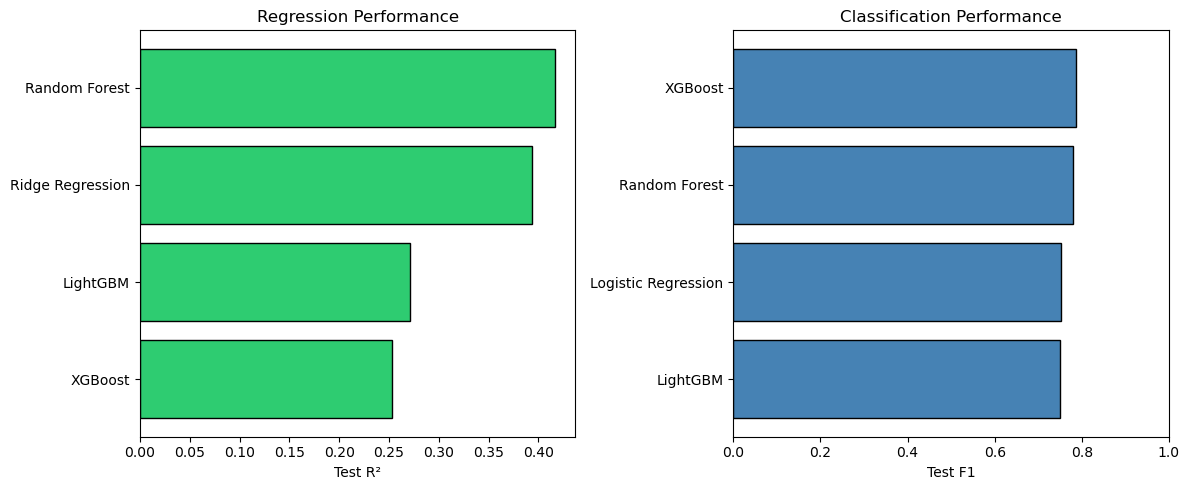

In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression R²
ax = axes[0]
reg_df = results_df[results_df['Type'] == 'Regression'].sort_values('Test_R2', ascending=True)
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in reg_df['Test_R2']]
ax.barh(reg_df['Model'], reg_df['Test_R2'], color=colors, edgecolor='black')
ax.set_xlabel('Test R²')
ax.set_title('Regression Performance')
ax.axvline(0, color='black', linewidth=0.5)

# Classification F1
ax = axes[1]
clf_df = results_df[results_df['Type'] == 'Classification'].sort_values('Test_F1', ascending=True)
ax.barh(clf_df['Model'], clf_df['Test_F1'], color='steelblue', edgecolor='black')
ax.set_xlabel('Test F1')
ax.set_title('Classification Performance')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 5. Feature Importance

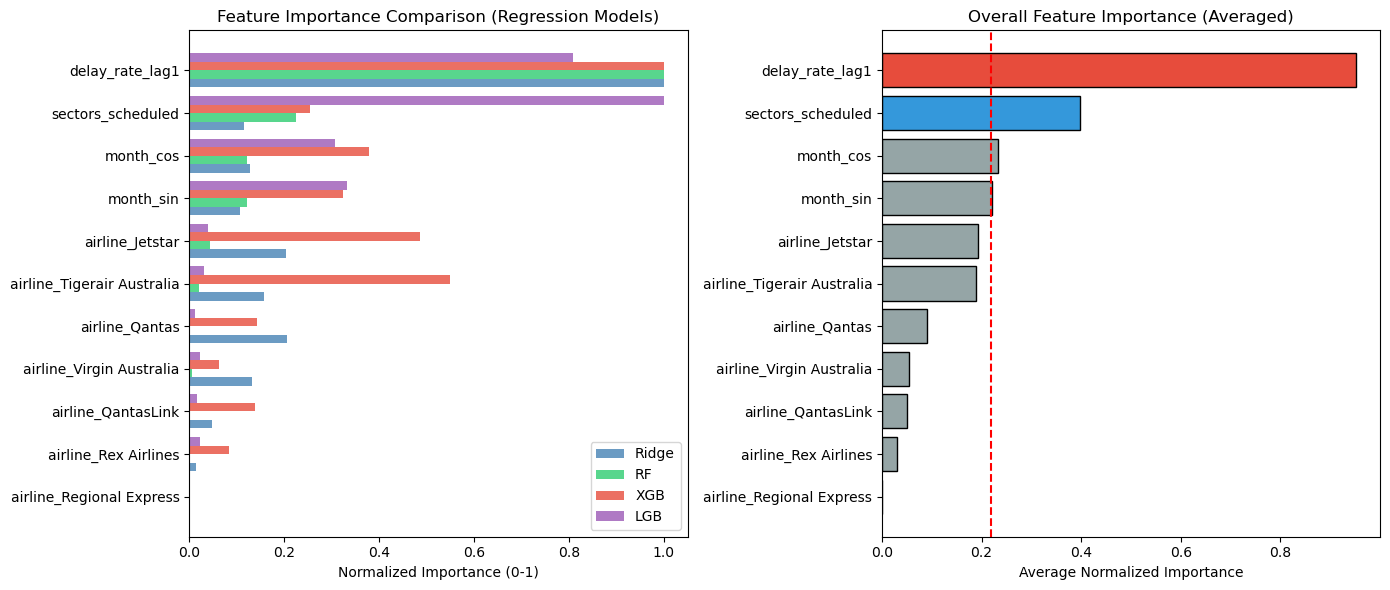

In [19]:
# Compare feature importance across ALL regression models
# Normalize importances to 0-1 scale for fair comparison

def normalize_importance(imp):
    """Normalize importance scores to 0-1 range"""
    return (imp - imp.min()) / (imp.max() - imp.min() + 1e-10)

# Collect importances from all regression models
importance_df = pd.DataFrame({'feature': features})

# Ridge (absolute coefficients)
importance_df['Ridge'] = normalize_importance(np.abs(ridge.coef_))

# Random Forest
importance_df['RF'] = normalize_importance(rf_reg.feature_importances_)

# XGBoost
if HAS_XGB:
    importance_df['XGB'] = normalize_importance(xgb_reg.feature_importances_)

# LightGBM
if HAS_LGB:
    importance_df['LGB'] = normalize_importance(lgb_reg.feature_importances_)

# Calculate average normalized importance
model_cols = ['Ridge', 'RF']
if HAS_XGB:
    model_cols.append('XGB')
if HAS_LGB:
    model_cols.append('LGB')

importance_df['Avg_Importance'] = importance_df[model_cols].mean(axis=1)

# Calculate rank for each model (1 = most important)
for col in model_cols:
    importance_df[f'{col}_rank'] = importance_df[col].rank(ascending=False)

rank_cols = [f'{col}_rank' for col in model_cols]
importance_df['Avg_Rank'] = importance_df[rank_cols].mean(axis=1)

# Sort by average importance
importance_df = importance_df.sort_values('Avg_Importance', ascending=False)

# Visualization: Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Grouped bar chart of normalized importance
ax = axes[0]
x = np.arange(len(features))
width = 0.2
colors = ['steelblue', '#2ecc71', '#e74c3c', '#9b59b6']

for i, col in enumerate(model_cols):
    sorted_imp = importance_df.sort_values('Avg_Importance', ascending=True)
    ax.barh(x + i*width, sorted_imp[col], width, label=col, color=colors[i], alpha=0.8)

ax.set_yticks(x + width * (len(model_cols)-1) / 2)
ax.set_yticklabels(importance_df.sort_values('Avg_Importance', ascending=True)['feature'])
ax.set_xlabel('Normalized Importance (0-1)')
ax.set_title('Feature Importance Comparison (Regression Models)')
ax.legend(loc='lower right')

# Right: Average importance bar chart
ax = axes[1]
sorted_df = importance_df.sort_values('Avg_Importance', ascending=True)
colors_avg = ['#e74c3c' if 'lag1' in f else '#3498db' if 'sector' in f else '#95a5a6' for f in sorted_df['feature']]
ax.barh(sorted_df['feature'], sorted_df['Avg_Importance'], color=colors_avg, edgecolor='black')
ax.set_xlabel('Average Normalized Importance')
ax.set_title('Overall Feature Importance (Averaged)')
ax.axvline(sorted_df['Avg_Importance'].mean(), color='red', linestyle='--', label='Mean')

plt.tight_layout()
plt.show()

In [20]:
# Feature Importance Ranking Summary Table
print("=" * 80)
print("FEATURE IMPORTANCE RANKING (Regression Models)")
print("=" * 80)
print("\nRank 1 = Most Important | Normalized Importance: 0 = Least, 1 = Most")
print()

# Create display table
display_cols = ['feature', 'Avg_Rank'] + model_cols + ['Avg_Importance']
display_df = importance_df[display_cols].copy()
display_df = display_df.sort_values('Avg_Rank')

# Round for display
for col in model_cols + ['Avg_Importance']:
    display_df[col] = display_df[col].round(3)
display_df['Avg_Rank'] = display_df['Avg_Rank'].round(1)

print(display_df.to_string(index=False))

# Key findings
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Find top 3 features
top3 = importance_df.head(3)['feature'].tolist()
print(f"\n🔝 Top 3 features (by average importance):")
for i, f in enumerate(top3, 1):
    avg_imp = importance_df[importance_df['feature'] == f]['Avg_Importance'].values[0]
    print(f"   {i}. {f} (avg importance: {avg_imp:.3f})")

# Specifically answer about sectors_scheduled
sectors_row = importance_df[importance_df['feature'] == 'sectors_scheduled']
if len(sectors_row) > 0:
    sectors_rank = sectors_row['Avg_Rank'].values[0]
    sectors_imp = sectors_row['Avg_Importance'].values[0]
    print(f"\n📊 sectors_scheduled analysis:")
    print(f"   - Average rank: {sectors_rank:.1f} out of {len(features)} features")
    print(f"   - Average importance: {sectors_imp:.3f}")
    if sectors_rank <= 3:
        print("   ✓ HELPFUL: sectors_scheduled is a top predictor")
    elif sectors_rank <= 6:
        print("   ~ MODERATE: sectors_scheduled has some predictive value")
    else:
        print("   ✗ LIMITED: sectors_scheduled contributes little to predictions")

# Compare lag1 vs month vs airline importance
lag1_imp = importance_df[importance_df['feature'] == 'delay_rate_lag1']['Avg_Importance'].values[0]
month_imp = importance_df[importance_df['feature'].isin(['month_sin', 'month_cos'])]['Avg_Importance'].mean()
airline_imp = importance_df[importance_df['feature'].str.startswith('airline_')]['Avg_Importance'].mean()

print(f"\n📈 Feature group comparison (avg normalized importance):")
print(f"   - delay_rate_lag1: {lag1_imp:.3f}")
print(f"   - Month (sin/cos): {month_imp:.3f}")
print(f"   - Airlines:        {airline_imp:.3f}")

FEATURE IMPORTANCE RANKING (Regression Models)

Rank 1 = Most Important | Normalized Importance: 0 = Least, 1 = Most

                   feature  Avg_Rank  Ridge    RF   XGB   LGB  Avg_Importance
           delay_rate_lag1       1.2  1.000 1.000 1.000 0.809           0.952
         sectors_scheduled       4.0  0.115 0.225 0.254 1.000           0.398
           airline_Jetstar       4.0  0.204 0.043 0.486 0.039           0.193
                 month_cos       4.2  0.128 0.121 0.379 0.307           0.234
airline_Tigerair Australia       4.5  0.157 0.020 0.549 0.031           0.189
                 month_sin       5.0  0.106 0.121 0.323 0.332           0.221
            airline_Qantas       6.8  0.205 0.002 0.143 0.011           0.090
  airline_Virgin Australia       7.4  0.131 0.005 0.062 0.022           0.055
        airline_QantasLink       8.8  0.048 0.000 0.138 0.016           0.051
      airline_Rex Airlines       9.1  0.013 0.000 0.083 0.022           0.030
  airline_Regional Expre

CLASSIFICATION MODEL FEATURE IMPORTANCE


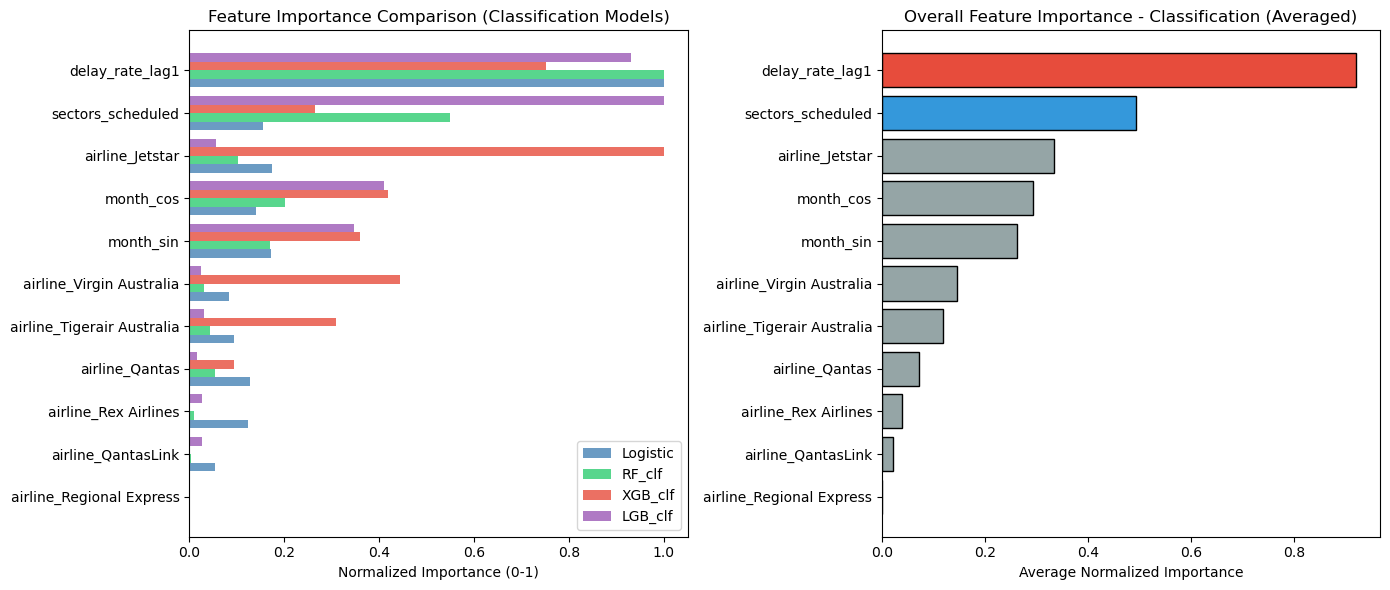


🎯 Top 3 features for classification:
   1. delay_rate_lag1 (avg: 0.921)
   2. sectors_scheduled (avg: 0.492)
   3. airline_Jetstar (avg: 0.333)


In [21]:
# Classification Model Feature Importance
print("=" * 80)
print("CLASSIFICATION MODEL FEATURE IMPORTANCE")
print("=" * 80)

# Collect classification model importances
clf_importance_df = pd.DataFrame({'feature': features})

# Logistic Regression (absolute coefficients)
clf_importance_df['Logistic'] = normalize_importance(np.abs(logreg.coef_[0]))

# Random Forest Classifier
clf_importance_df['RF_clf'] = normalize_importance(rf_clf.feature_importances_)

# XGBoost Classifier
if HAS_XGB:
    clf_importance_df['XGB_clf'] = normalize_importance(xgb_clf.feature_importances_)

# LightGBM Classifier
if HAS_LGB:
    clf_importance_df['LGB_clf'] = normalize_importance(lgb_clf.feature_importances_)

# Calculate average
clf_model_cols = ['Logistic', 'RF_clf']
if HAS_XGB:
    clf_model_cols.append('XGB_clf')
if HAS_LGB:
    clf_model_cols.append('LGB_clf')

clf_importance_df['Avg_Importance'] = clf_importance_df[clf_model_cols].mean(axis=1)
clf_importance_df = clf_importance_df.sort_values('Avg_Importance', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Grouped bar chart
ax = axes[0]
x = np.arange(len(features))
width = 0.2
colors = ['steelblue', '#2ecc71', '#e74c3c', '#9b59b6']

for i, col in enumerate(clf_model_cols):
    sorted_imp = clf_importance_df.sort_values('Avg_Importance', ascending=True)
    ax.barh(x + i*width, sorted_imp[col], width, label=col, color=colors[i], alpha=0.8)

ax.set_yticks(x + width * (len(clf_model_cols)-1) / 2)
ax.set_yticklabels(clf_importance_df.sort_values('Avg_Importance', ascending=True)['feature'])
ax.set_xlabel('Normalized Importance (0-1)')
ax.set_title('Feature Importance Comparison (Classification Models)')
ax.legend(loc='lower right')

# Right: Average importance
ax = axes[1]
sorted_clf = clf_importance_df.sort_values('Avg_Importance', ascending=True)
colors_avg = ['#e74c3c' if 'lag1' in f else '#3498db' if 'sector' in f else '#95a5a6' for f in sorted_clf['feature']]
ax.barh(sorted_clf['feature'], sorted_clf['Avg_Importance'], color=colors_avg, edgecolor='black')
ax.set_xlabel('Average Normalized Importance')
ax.set_title('Overall Feature Importance - Classification (Averaged)')

plt.tight_layout()
plt.show()

# Print top features for classification
print("\n🎯 Top 3 features for classification:")
for i, row in clf_importance_df.head(3).iterrows():
    print(f"   {clf_importance_df.head(3).index.get_loc(i)+1}. {row['feature']} (avg: {row['Avg_Importance']:.3f})")

## 6. Summary

In [24]:
# Find best models
best_reg = reg_results.iloc[0]
best_clf = clf_results.iloc[0]

print("=" * 70)
print("BEST PERFORMING MODELS")
print("=" * 70)

print(f"\n📊 REGRESSION TASK (predict delay_rate):")
print(f"   Best model: {best_reg['Model']}")
print(f"   Test R²: {best_reg['Test_R2']:.4f}")
print(f"   Test RMSE: {best_reg['Test_RMSE']:.4f}")

print(f"\n🎯 CLASSIFICATION TASK (predict is_high_delay):")
print(f"   Best model: {best_clf['Model']}")
print(f"   Test F1: {best_clf['Test_F1']:.4f}")
print(f"   Test AUC: {best_clf['Test_AUC']:.4f}")


BEST PERFORMING MODELS

📊 REGRESSION TASK (predict delay_rate):
   Best model: Random Forest
   Test R²: 0.4163
   Test RMSE: 0.0755

🎯 CLASSIFICATION TASK (predict is_high_delay):
   Best model: XGBoost
   Test F1: 0.7876
   Test AUC: 0.8206


### Observations:
- _delay_rate_lag1_ is the most important feature across all models
- Adding _sectors_scheduled_ is a success, this feature leads from the rest of the other features
- For regression model: using RF (more complex) over ridge regression adds 0.0231 to the test R²
   - This is <5%, not worth the switch to a more complex model
   - Ridge regression is relatively easier to interpret and less prone to overfitting
- For classification using XGB (more complex) over logistic regression adds +0.0346 to the test F1 score
   - Similar to the justifications for regression, using the simpler option is preferred
   - Logisitic regression still has the best AUC
- At this point, the model essentially learns that 'next month will be similar to this month' with some adjustments for flight volume, airline and seasonal patterns.

## 7. Next step

Based on the success of adding _sectors_scheduled_, will continue to add one feature at a time. Next, reintroduce the weather feature with the highest relative importance: number of rainy days.